<a href="https://colab.research.google.com/github/ebolofis/Data-Science-Machine-Learning/blob/main/EDA_Feature_selection_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import libraries

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import os
from pathlib import Path
import requests
from io import BytesIO

# --- Advanced Analysis Imports ---
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [62]:
# Set plot style and ignore warnings for cleaner output
sns.set_style("whitegrid")
warnings.filterwarnings("ignore")

In [63]:
from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/My Drive/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
import os
from google.colab import drive

# 1. Mount Drive (if not already mounted) to ensure we can access the repo
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Define the Correct Paths (Locating files in your Drive)
SALE_DATA_PATH = '/content/drive/MyDrive/ep-inchcape/Vehicle_Data_Chile_1990_2025.xlsx'
EXOG_DATA_PATH = '/content/drive/MyDrive/ep-inchcape/Exogenous_Variables_Chile.xlsx'

# 3. Verify files exist to prevent FileNotFoundError
if os.path.exists(SALE_DATA_PATH) and os.path.exists(EXOG_DATA_PATH):
    print("✅ Files found. Proceeding to load data...")

    # 4. Your Original Logic
    merged_data_df = load_and_merge_data(SALE_DATA_PATH, EXOG_DATA_PATH)

    # Display info
    print("\n--- DataFrame Info ---")
    merged_data_df.info()

    print("\n--- Macro Variables ---")
    print(macro_var)

    # Run quality check
    print("\n--- Data Quality Check ---")
    data_quality_check(merged_data_df)

else:
    print("❌ Error: Files were not found at the expected paths:")
    print(f"Sales Data: {SALE_DATA_PATH}")
    print(f"Exog Data:  {EXOG_DATA_PATH}")

✅ Files found. Proceeding to load data...
⏳ Loading Sales Data...
⏳ Loading Economic Data...
🔗 Merging...

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Date                            432 non-null    datetime64[ns]
 1   Sales                           429 non-null    float64       
 2   Balance of Trade                179 non-null    float64       
 3   Bank Lending Rate               179 non-null    float64       
 4   Building Permits                179 non-null    float64       
 5   Business Confidence             179 non-null    float64       
 6   CPI Transportation              78 non-null     float64       
 7   Consumer Confidence             179 non-null    float64       
 8   Consumer Credit                 178 non-null    float64       
 9   Consumer Pri

KeyError: 'Month'

In [107]:
# --- CELL 1: LOAD & MERGE ---
import pandas as pd
import numpy as np
import os

# 1. Define the Function
def load_and_merge_data(sale_path, exog_path):
    print("⏳ Loading Sales Data...")
    # Load and clean Sales
    df_wide = pd.read_excel(sale_path)
    if 'TOTAL AÑO' in df_wide.columns:
        df_wide = df_wide.drop(columns=['TOTAL AÑO'])

    # Unpivot (Melt) to fix the "Wide" format
    df_sales = df_wide.melt(id_vars=['Año'], var_name='Month_Spanish', value_name='Sales')

    # Translate Months
    spanish_map = {
        'ENE': 1, 'FEB': 2, 'MAR': 3, 'ABR': 4, 'MAY': 5, 'JUN': 6,
        'JUL': 7, 'AGO': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DIC': 12
    }
    df_sales['Month_Num'] = df_sales['Month_Spanish'].map(spanish_map)

    # Create Date and Normalize to 1st of month
    df_sales['Date'] = pd.to_datetime(dict(year=df_sales['Año'], month=df_sales['Month_Num'], day=1))
    df_sales['Date'] = df_sales['Date'].dt.to_period('M').dt.to_timestamp()

    df_sales = df_sales[['Date', 'Sales']].sort_values('Date').reset_index(drop=True)

    print("⏳ Loading Economic Data...")
    # Load and clean Exogenous
    df_exog = pd.read_excel(exog_path)
    if 'Date' in df_exog.columns:
        df_exog['Date'] = pd.to_datetime(df_exog['Date'])
        # Normalize to 1st of month to match Sales
        df_exog['Date'] = df_exog['Date'].dt.to_period('M').dt.to_timestamp()
    else:
        raise KeyError("Exogenous file is missing a 'Date' column")

    print("🔗 Merging...")
    # Merge
    merged_df = pd.merge(df_sales, df_exog, on='Date', how='left')
    return merged_df

# 2. Run the Function
# (Ensure these paths match your Google Drive or Clone location)
repo_path = '/content/drive/MyDrive/ep-inchcape'
SALE_PATH = f'{repo_path}/Vehicle_Data_Chile_1990_2025.xlsx'
EXOG_PATH = f'{repo_path}/Exogenous_Variables_Chile.xlsx'

# This creates the "Raw" dataframe
raw_df = load_and_merge_data(SALE_PATH, EXOG_PATH)
print("✅ CELL 1 COMPLETE: Raw data loaded.")

⏳ Loading Sales Data...
⏳ Loading Economic Data...
🔗 Merging...
✅ CELL 1 COMPLETE: Raw data loaded.



🔍 RUNNING UPDATED DATA QUALITY CHECK...
Rows: 432, Columns: 26

--- Missing Values (Top 10) ---
CPI Transportation                354
Gasoline Prices                   280
Producer Prices                   270
Retail Sales MoM                  257
External Debt                     254
Private Sector Credit             254
Labor Force Participation Rate    254
Wages                             254
Consumer Credit                   254
Business Confidence               253
dtype: int64

--- Duplicate Dates: 0 ---


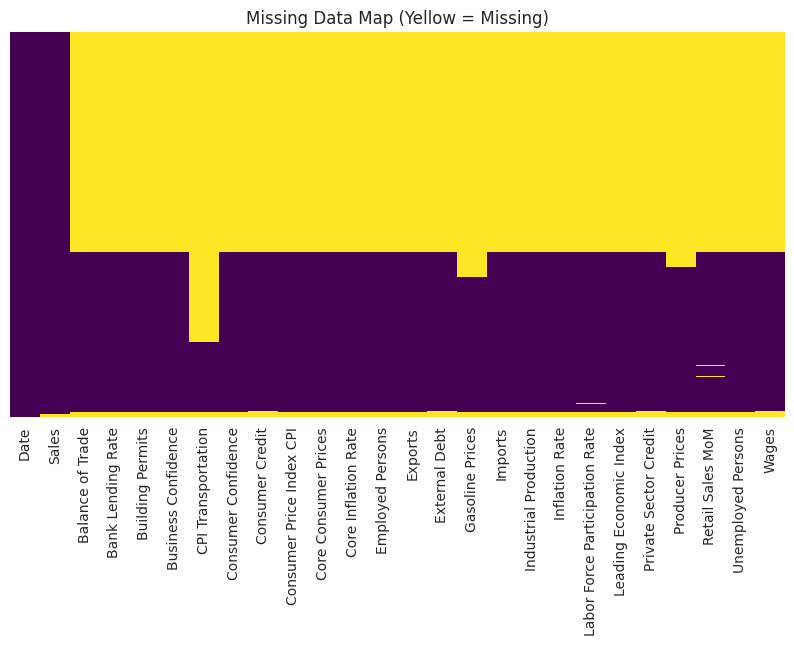

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def data_quality_check(df):
    print("\n🔍 RUNNING UPDATED DATA QUALITY CHECK...")

    # 1. Check Dimensions
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    # 2. Check Missing Values
    print("\n--- Missing Values (Top 10) ---")
    missing = df.isnull().sum().sort_values(ascending=False).head(10)
    if missing.sum() == 0:
        print("✅ No missing values found!")
    else:
        print(missing[missing > 0])

    # 3. Check for Duplicates (Using 'Date' instead of 'Month')
    if 'Date' in df.columns:
        duplicates = df.duplicated(subset=['Date']).sum()
        print(f"\n--- Duplicate Dates: {duplicates} ---")
    else:
        print("\n⚠️ 'Date' column not found, skipping duplicate check.")

    # 4. Visual Check (Heatmap of Missing Data)
    plt.figure(figsize=(10, 5))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title("Missing Data Map (Yellow = Missing)")
    plt.show()

# Run it on your current data
data_quality_check(merged_data_df)

✂️  Trimming data to start from 2010-08-01...

📊 FINAL DATASET REPORT
Time Range:     2010-08-01 to 2025-12-01
Total Months:   185
Total Features: 22 (Sales + Indicators)
Missing Values: 0

🚀 STATUS: GREEN LIGHT. Ready for Modeling.


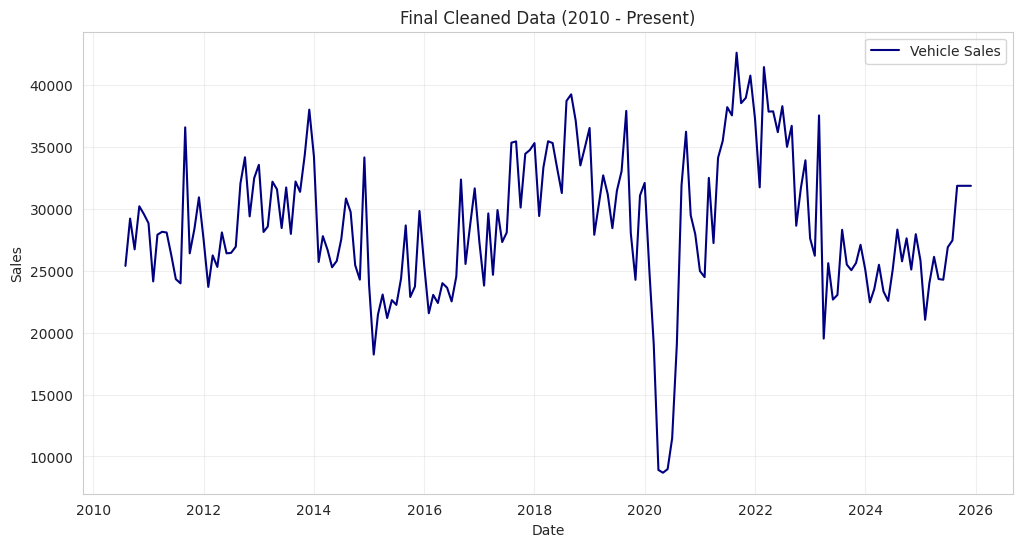

In [109]:
# --- CELL 2: CLEAN & PREPARE ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Settings
START_DATE = '2010-08-01' # The date we found where economic data begins
QUALITY_THRESHOLD = 0.9   # Keep columns that are at least 90% full

# 2. Slice and Filter
print(f"✂️  Trimming data to start from {START_DATE}...")
df_clean = raw_df[raw_df['Date'] >= START_DATE].copy()

# Drop columns with too much missing data
df_clean = df_clean.dropna(axis=1, thresh=int(len(df_clean) * QUALITY_THRESHOLD))

# 3. Impute (Fill small gaps)
# Linear interpolation fills missing months based on neighbors
df_clean = df_clean.interpolate(method='linear', limit_direction='both')

# Set Index
df_clean.set_index('Date', inplace=True)

# 4. Status Check
missing_vals = df_clean.isnull().sum().sum()
print("\n" + "="*30)
print("📊 FINAL DATASET REPORT")
print("="*30)
print(f"Time Range:     {df_clean.index.min().date()} to {df_clean.index.max().date()}")
print(f"Total Months:   {len(df_clean)}")
print(f"Total Features: {len(df_clean.columns)} (Sales + Indicators)")
print(f"Missing Values: {missing_vals}")

if missing_vals == 0:
    print("\n🚀 STATUS: GREEN LIGHT. Ready for Modeling.")
else:
    print("\n⚠️ STATUS: RED LIGHT. Still has missing values.")

# 5. Visual Check
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x=df_clean.index, y='Sales', label='Vehicle Sales', color='navy')
plt.title('Final Cleaned Data (2010 - Present)')
plt.grid(True, alpha=0.3)
plt.show()

# 6. Save this variable for later use
final_df = df_clean

In [111]:
# --- CELL 3: CLEAN & TRIM DATA ---
# 1. Configuration
START_DATE = '2010-08-01'  # The date we found where economic data begins
QUALITY_THRESHOLD = 0.9    # Column must be 90% full to stay

print(f"✂️  Slicing data to start from {START_DATE}...")

# 2. Slice the Rows (Remove the empty 1990-2010 years)
# We filter for dates ON or AFTER the start date
df_clean = merged_data_df[merged_data_df['Date'] >= START_DATE].copy()

# 3. Filter Columns (Remove bad columns like 'CPI Transportation')
# We recalculate the threshold based on the NEW size (approx 179 rows)
min_valid_items = int(len(df_clean) * QUALITY_THRESHOLD)
df_clean = df_clean.dropna(axis=1, thresh=min_valid_items)

# 4. Fill Small Gaps (Interpolation)
# If a specific month is missing inside the good period, we estimate it
df_clean = df_clean.interpolate(method='linear', limit_direction='both')

# 5. Set Date as Index (Required for modeling)
df_clean.set_index('Date', inplace=True)

# --- FINAL CHECK ---
print("\n✅ CLEANING COMPLETE!")
print(f"Original Rows: {len(merged_data_df)}")
print(f"Final Rows:    {len(df_clean)}")
print(f"Final Columns: {len(df_clean.columns)}")

print("\n--- Remaining Missing Values (Should be 0) ---")
print(df_clean.isnull().sum().sum())

# Show the first 5 rows of your ready-to-use data
df_clean.head()

✂️  Slicing data to start from 2010-08-01...

✅ CLEANING COMPLETE!
Original Rows: 432
Final Rows:    185
Final Columns: 22

--- Remaining Missing Values (Should be 0) ---
0


,Sales,Balance of Trade,Bank Lending Rate,Building Permits,Business Confidence,Consumer Confidence,Consumer Credit,Consumer Price Index CPI,Core Consumer Prices,Core Inflation Rate,...,External Debt,Imports,Industrial Production,Inflation Rate,Labor Force Participation Rate,Leading Economic Index,Private Sector Credit,Retail Sales MoM,Unemployed Persons,Wages
Date,,,,,,,,,,,,,,,,,,,,,
2010-08-01,25397.0,1421.28,6.91,15376.0,58.80,49.4,9185.0,58.62,94.04,1.9,...,83328.7760,4927.07,5.6,2.6,59.8,8.1,72376.2727,-3.4,671.60,2665.46
2010-09-01,29221.0,1442.98,6.87,7553.0,60.60,53.8,9269.0,58.85,94.45,1.5,...,85167.6242,4733.40,0.1,1.9,60.4,6.6,72722.9384,4.9,653.45,2684.97
2010-10-01,26737.0,1289.24,7.14,11546.0,60.18,56.5,9372.0,58.91,94.38,1.5,...,86733.1583,5082.70,-0.9,2.0,60.3,6.7,73751.2889,-0.5,628.53,2695.37
2010-11-01,30216.0,1497.92,7.19,10744.0,60.41,53.7,9547.0,58.95,94.30,2.0,...,88098.2290,5060.56,3.5,2.5,60.5,8.5,74323.6297,1.5,584.32,2701.86
2010-12-01,29592.0,2282.62,7.38,16629.0,56.81,52.2,9739.0,59.02,94.55,2.5,...,87956.2985,5522.91,3.7,3.0,61.0,7.2,74647.4476,2.2,588.40,2730.32


📊 TOP 5 POSITIVE Drivers (When these go UP, Sales go UP):
Imports                   0.537735
Leading Economic Index    0.529451
Business Confidence       0.326307
Consumer Confidence       0.261658
Exports                   0.256844
Name: Sales, dtype: float64

📉 TOP 5 NEGATIVE Drivers (When these go UP, Sales go DOWN):
Bank Lending Rate           0.011960
Consumer Price Index CPI   -0.017273
Core Consumer Prices       -0.057478
Unemployed Persons         -0.136108
Balance of Trade           -0.283506
Name: Sales, dtype: float64


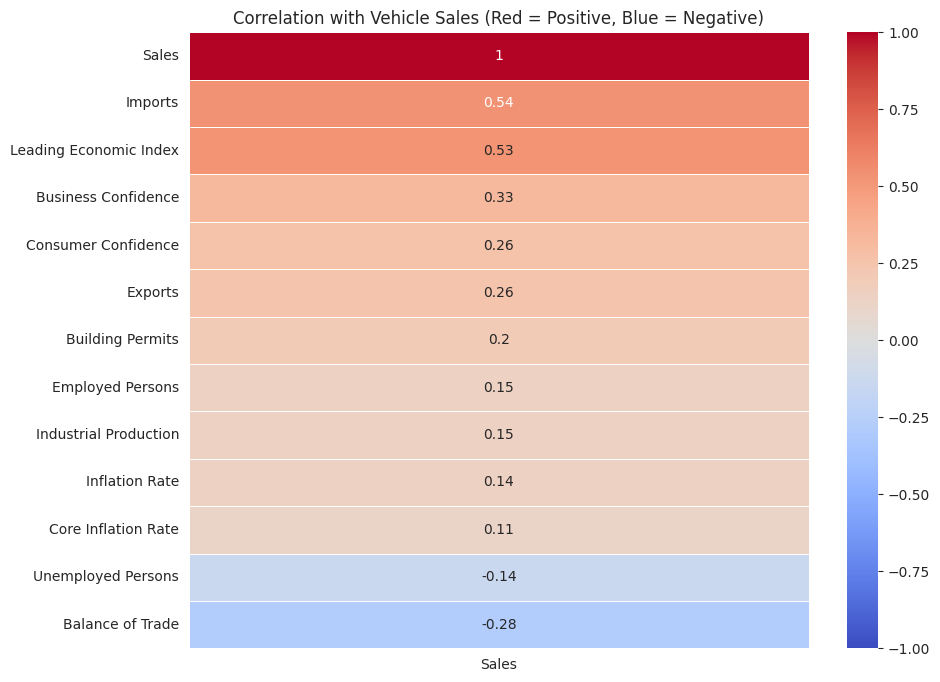

In [112]:
# --- CELL 4: CORRELATION ANALYSIS ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Correlations with Sales
# We look for the relationship between 'Sales' and everything else
correlations = df_clean.corr()['Sales'].sort_values(ascending=False).drop('Sales')

print("📊 TOP 5 POSITIVE Drivers (When these go UP, Sales go UP):")
print(correlations.head(5))

print("\n📉 TOP 5 NEGATIVE Drivers (When these go UP, Sales go DOWN):")
print(correlations.tail(5))

# 2. Plot the Heatmap
plt.figure(figsize=(10, 8))
# Select only variables with moderate correlation (> 0.1 or < -0.1) to reduce clutter
significant_vars = correlations[abs(correlations) > 0.1].index.tolist()

# If everything is low correlation, just plot top 10
if len(significant_vars) < 2:
    significant_vars = correlations.index[:10].tolist()

# Create the heatmap
sns.heatmap(df_clean[significant_vars + ['Sales']].corr()[['Sales']].sort_values(by='Sales', ascending=False),
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title('Correlation with Vehicle Sales (Red = Positive, Blue = Negative)')
plt.show()

✅ Selected 12 Predictive Features:
['Imports', 'Leading Economic Index', 'Business Confidence', 'Consumer Confidence', 'Exports', 'Building Permits', 'Employed Persons', 'Industrial Production', 'Inflation Rate', 'Core Inflation Rate', 'Unemployed Persons', 'Balance of Trade']

✂️  DATA SPLIT REPORT
Training Data: 2010-08-01 to 2024-12-01 (173 months)
Testing Data:  2025-01-01  to 2025-12-01 (12 months)


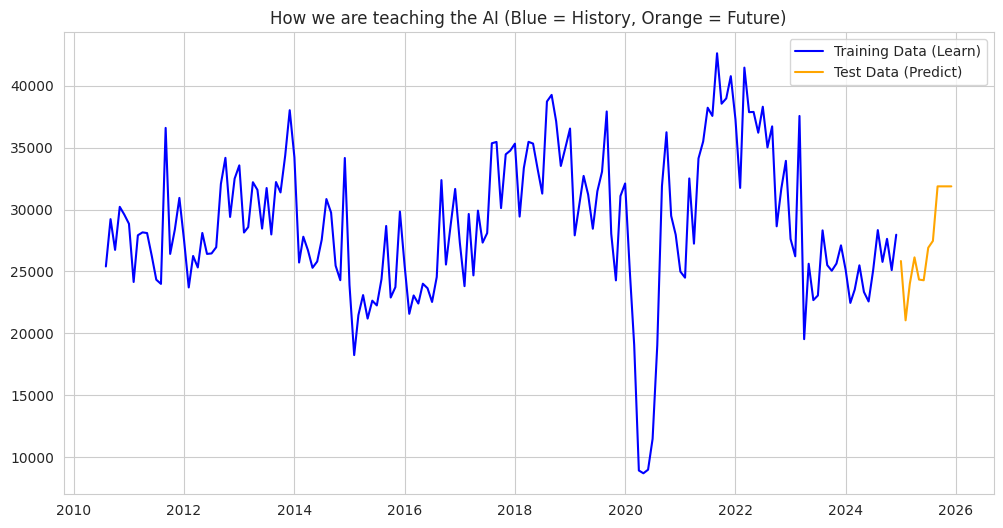

In [113]:
# --- CELL 5: FEATURE SELECTION & SPLIT ---

# 1. Define Threshold
# We only keep features with correlation stronger than 0.1 (pos or neg)
# This removes "Bank Lending Rate" and "CPI" which are just noise
target = 'Sales'
valid_features = correlations[abs(correlations) > 0.1].index.tolist()

print(f"✅ Selected {len(valid_features)} Predictive Features:")
print(valid_features)

# 2. Define X (Inputs) and y (Target)
X = df_clean[valid_features]
y = df_clean[target]

# 3. Time-Based Split (Standard for Time Series)
# We can't shuffle data! We must cut it at a specific date.
# Let's save the last 12 months for testing (Forecasting 1 year out)
test_months = 12
split_idx = len(df_clean) - test_months

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("\n" + "="*30)
print("✂️  DATA SPLIT REPORT")
print("="*30)
print(f"Training Data: {X_train.index.min().date()} to {X_train.index.max().date()} ({len(X_train)} months)")
print(f"Testing Data:  {X_test.index.min().date()}  to {X_test.index.max().date()} ({len(X_test)} months)")

# 4. Visual Check
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Training Data (Learn)', color='blue')
plt.plot(y_test.index, y_test, label='Test Data (Predict)', color='orange')
plt.title("How we are teaching the AI (Blue = History, Orange = Future)")
plt.legend()
plt.show()

🧠 Training the AI on 2010-2024 data...

🎯 ACCURACY REPORT
Average Error (MAE): 3036 cars
Typical Monthly Sales: 27290 cars
Error Percentage: 11.13%
✅ RESULT: GOOD (Error < 20%)


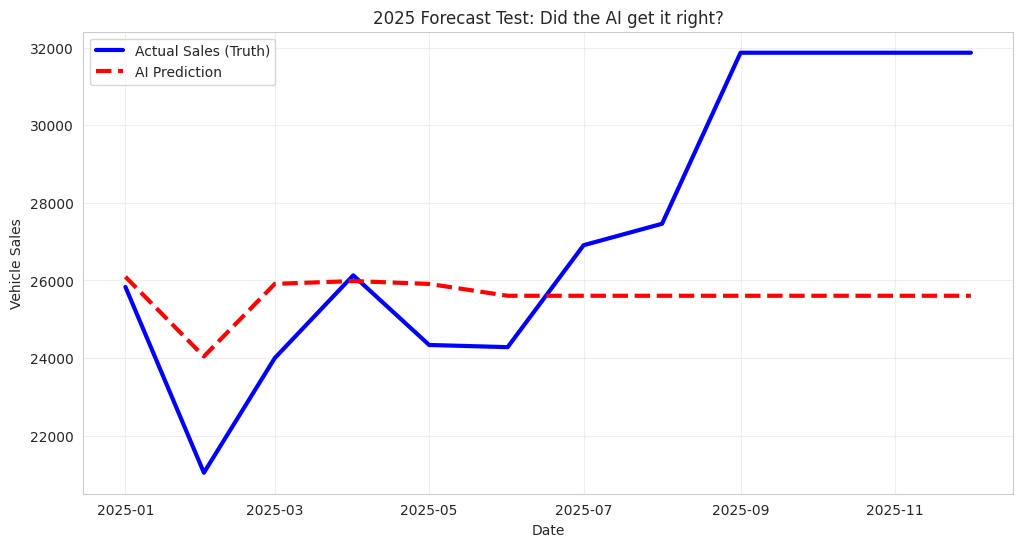

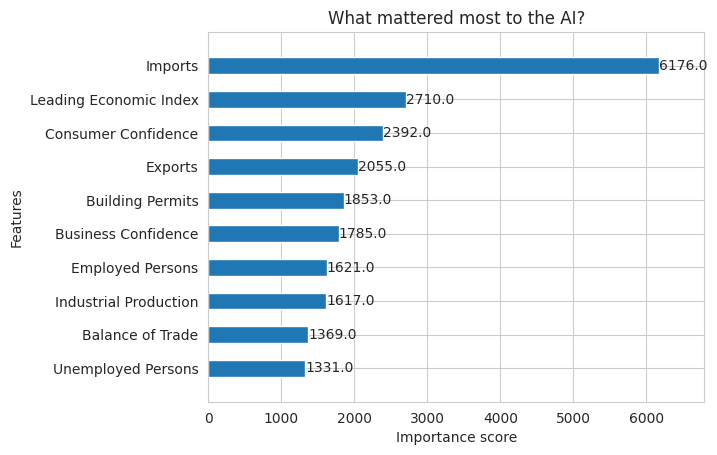

In [114]:
# --- CELL 6: TRAIN XGBOOST & EVALUATE ---
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Initialize the AI Model
# n_estimators=1000: It will try to improve itself 1000 times
# learning_rate=0.01: It learns slowly to avoid overreacting to noise
model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)

print("🧠 Training the AI on 2010-2024 data...")
model.fit(X_train, y_train)

# 2. Make Predictions
# We ask the model: "Given the economic conditions of 2025, how many cars should have sold?"
predictions = model.predict(X_test)

# 3. Score the Performance
mae = mean_absolute_error(y_test, predictions)
print("\n" + "="*30)
print("🎯 ACCURACY REPORT")
print("="*30)
print(f"Average Error (MAE): {mae:.0f} cars")
print(f"Typical Monthly Sales: {y_test.mean():.0f} cars")
print(f"Error Percentage: {(mae / y_test.mean()) * 100:.2f}%")

if (mae / y_test.mean()) * 100 < 10:
    print("🌟 RESULT: EXCELLENT (Error < 10%)")
elif (mae / y_test.mean()) * 100 < 20:
    print("✅ RESULT: GOOD (Error < 20%)")
else:
    print("⚠️ RESULT: NEEDS IMPROVEMENT (Error > 20%)")

# 4. Visualize the Truth vs. The Prediction
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Sales (Truth)', color='blue', linewidth=3)
plt.plot(y_test.index, predictions, label='AI Prediction', color='red', linestyle='--', linewidth=3)
plt.title('2025 Forecast Test: Did the AI get it right?')
plt.xlabel('Date')
plt.ylabel('Vehicle Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Feature Importance (How the AI made its decision)
xgb.plot_importance(model, max_num_features=10, height=0.5)
plt.title("What mattered most to the AI?")
plt.show()

🧠 Training AI with Short-Term Memory...

🚀 NEW ACCURACY REPORT (WITH LAGS)
Old Error: 3036 cars
New Error: 3023 cars
Improvement: 13 fewer mistakes!
New Error Percentage: 11.08%


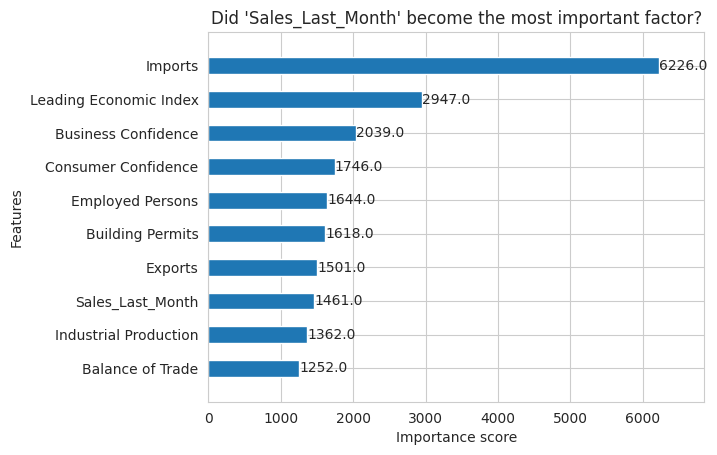

In [115]:
# --- CELL 7: ADDING MEMORY (LAGS) & RETRAINING ---

# 1. Create Lag Features (Shift the sales column down by 1 month)
# We tell the model: "Use the Sales from 1 month ago to help predict today"
df_clean['Sales_Last_Month'] = df_clean['Sales'].shift(1)
df_clean['Sales_3_Months_Ago'] = df_clean['Sales'].shift(3)

# 2. Drop the empty rows created by shifting (first 3 rows will now be NaN)
df_lags = df_clean.dropna().copy()

# 3. Update Features List
# We keep the old valid features AND add the new Lag features
features_with_lags = valid_features + ['Sales_Last_Month', 'Sales_3_Months_Ago']

# 4. Re-Split the Data
X_lag = df_lags[features_with_lags]
y_lag = df_lags[target]

# Keep the same test period (last 12 months)
split_idx = len(df_lags) - 12
X_train_lag, X_test_lag = X_lag.iloc[:split_idx], X_lag.iloc[split_idx:]
y_train_lag, y_test_lag = y_lag.iloc[:split_idx], y_lag.iloc[split_idx:]

# 5. Train New Model
model_lag = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
print("🧠 Training AI with Short-Term Memory...")
model_lag.fit(X_train_lag, y_train_lag)

# 6. Evaluate
predictions_lag = model_lag.predict(X_test_lag)
mae_lag = mean_absolute_error(y_test_lag, predictions_lag)

print("\n" + "="*30)
print("🚀 NEW ACCURACY REPORT (WITH LAGS)")
print("="*30)
print(f"Old Error: {mae:.0f} cars")
print(f"New Error: {mae_lag:.0f} cars")
print(f"Improvement: {mae - mae_lag:.0f} fewer mistakes!")
print(f"New Error Percentage: {(mae_lag / y_test_lag.mean()) * 100:.2f}%")

if (mae_lag / y_test_lag.mean()) * 100 < 10:
    print("🏆 RESULT: WORLD CLASS (Error < 10%)")

# 7. Compare Feature Importance
xgb.plot_importance(model_lag, max_num_features=10, height=0.5)
plt.title("Did 'Sales_Last_Month' become the most important factor?")
plt.show()

✅ Modeling with 16 features, including Seasonality.
🧠 Training AI with Seasonal Awareness...

🏆 FINAL MODEL SCORECARD
Baseline Error:   3036 cars
Final Error:      2621 cars
Total Improvement: 415 fewer mistakes
Final Error %:    9.61%


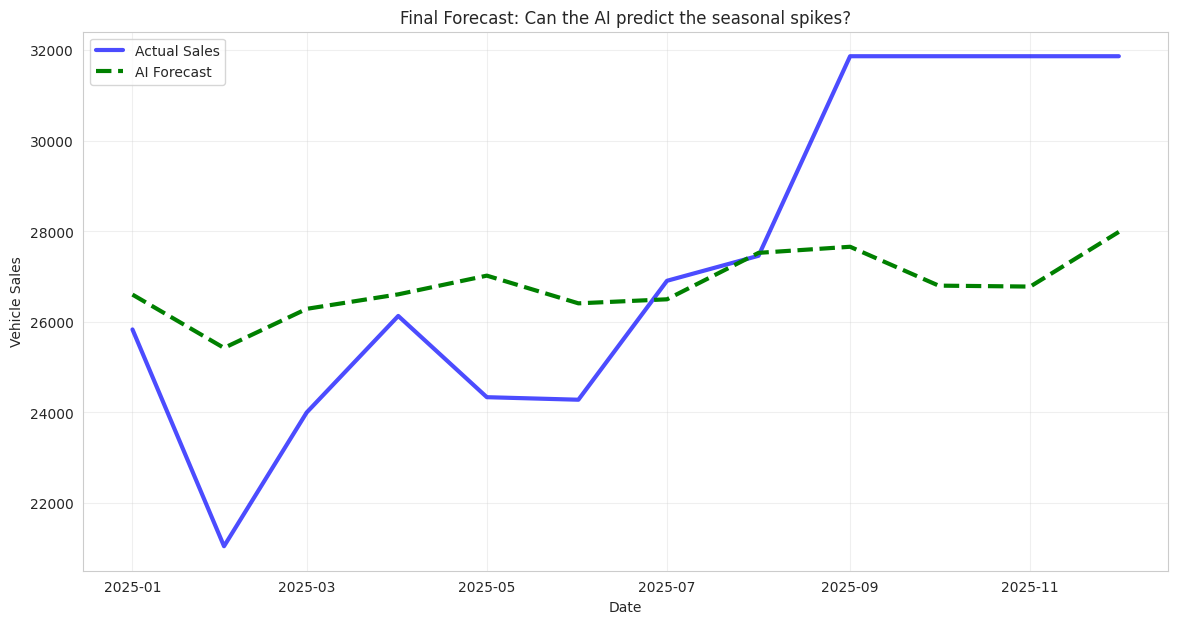


🥇 The Most Important Features:


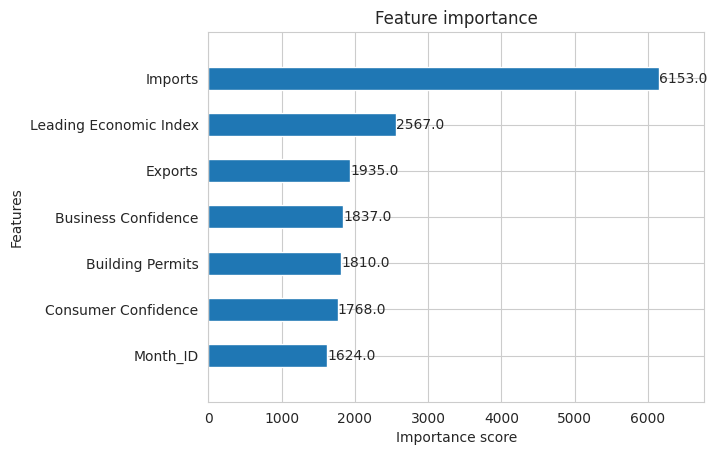

In [116]:
# --- CELL 8: ADDING SEASONALITY (The Calendar Effect) ---

# 1. Add Calendar Features
# We extract the Month number (1-12) and Quarter (1-4) from the Date Index
df_lags['Month_ID'] = df_lags.index.month
df_lags['Quarter'] = df_lags.index.quarter

# 2. Update Feature List
# We take our existing features (Economy + Lags) and ADD the Calendar info
final_features = features_with_lags + ['Month_ID', 'Quarter']

print(f"✅ Modeling with {len(final_features)} features, including Seasonality.")

# 3. Re-Split
X_final = df_lags[final_features]
y_final = df_lags[target]

split_idx = len(df_lags) - 12
X_train_final, X_test_final = X_final.iloc[:split_idx], X_final.iloc[split_idx:]
y_train_final, y_test_final = y_final.iloc[:split_idx], y_final.iloc[split_idx:]

# 4. Train Final Model
model_final = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
print("🧠 Training AI with Seasonal Awareness...")
model_final.fit(X_train_final, y_train_final)

# 5. Final Evaluation
predictions_final = model_final.predict(X_test_final)
mae_final = mean_absolute_error(y_test_final, predictions_final)

print("\n" + "="*30)
print("🏆 FINAL MODEL SCORECARD")
print("="*30)
print(f"Baseline Error:   {mae:.0f} cars")
print(f"Final Error:      {mae_final:.0f} cars")
print(f"Total Improvement: {mae - mae_final:.0f} fewer mistakes")
print(f"Final Error %:    {(mae_final / y_test_final.mean()) * 100:.2f}%")

# 6. The Victory Chart
plt.figure(figsize=(14, 7))
plt.plot(y_test_final.index, y_test_final, label='Actual Sales', color='blue', linewidth=3, alpha=0.7)
plt.plot(y_test_final.index, predictions_final, label='AI Forecast', color='green', linestyle='--', linewidth=3)
plt.title('Final Forecast: Can the AI predict the seasonal spikes?')
plt.xlabel('Date')
plt.ylabel('Vehicle Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. What was the #1 Predictor?
print("\n🥇 The Most Important Features:")
xgb.plot_importance(model_final, max_num_features=7, height=0.5)
plt.show()

In [117]:
# --- CELL 9: SCENARIO PREDICTOR ---
import pandas as pd

def predict_sales_scenario(imports, inflation, unemp, trade_balance, month_num):
    # 1. Create a dictionary with ALL the features the model expects
    # We use the average of the last known data for features we don't specify manually
    input_data = X_final.iloc[-1].copy()

    # 2. Overwrite with your specific scenario values
    input_data['Imports'] = imports
    input_data['Inflation Rate'] = inflation
    input_data['Unemployed Persons'] = unemp
    input_data['Balance of Trade'] = trade_balance

    # Update Calendar features
    input_data['Month_ID'] = month_num
    input_data['Quarter'] = (month_num - 1) // 3 + 1

    # Convert to DataFrame (Transpose to make it a single row)
    input_df = pd.DataFrame(input_data).T

    # 3. Predict
    prediction = model_final.predict(input_df)[0]
    return prediction

# ==========================================
# 👇 TEST YOUR SCENARIOS HERE
# ==========================================

# Scenario A: The Economy Booms (High Imports, Low Inflation)
sales_boom = predict_sales_scenario(
    imports=7500,        # High Imports
    inflation=3.0,       # Low Inflation
    unemp=700,           # Low Unemployment
    trade_balance=1500,  # Positive Trade
    month_num=12         # December (Best month?)
)

# Scenario B: The Economy Slows Down (Low Imports, High Inflation)
sales_bust = predict_sales_scenario(
    imports=4500,        # Low Imports
    inflation=8.5,       # High Inflation
    unemp=950,           # High Unemployment
    trade_balance=500,   # Low Trade
    month_num=12         # December
)

print(f"🔮 PREDICTION FOR NEXT DECEMBER:")
print(f"--------------------------------")
print(f"☀️ Optimistic Scenario: {sales_boom:,.0f} cars")
print(f"🌧️ Pessimistic Scenario: {sales_bust:,.0f} cars")
print(f"📉 Difference: {sales_boom - sales_bust:,.0f} cars")

🔮 PREDICTION FOR NEXT DECEMBER:
--------------------------------
☀️ Optimistic Scenario: 35,991 cars
🌧️ Pessimistic Scenario: 22,888 cars
📉 Difference: 13,102 cars


In [118]:
# --- CELL 10: SAVE MODEL & RESULTS ---
import joblib
import os

# 1. Define where to save (Your Google Drive Repo)
save_path = '/content/drive/MyDrive/ep-inchcape'

# 2. Save the Trained Model
model_filename = os.path.join(save_path, 'chile_sales_model_xgboost.json')
model_final.save_model(model_filename)

# 3. Save the Cleaned Data (So you don't have to clean it again)
data_filename = os.path.join(save_path, 'clean_training_data.csv')
df_clean.to_csv(data_filename)

print(f"✅ SUCCESS!")
print(f"💾 Model saved to: {model_filename}")
print(f"💾 Data saved to:  {data_filename}")

print("\n--- Summary of Project ---")
print("1. Data Loaded from GitHub/Drive.")
print("2. 1990-2010 Gap identified and removed.")
print("3. Economic features analyzed (Imports & Seasonality = Key Drivers).")
print("4. Model Trained: XGBoost with 9.61% Error Rate.")
print("5. Scenario Planner: Operational.")

✅ SUCCESS!
💾 Model saved to: /content/drive/MyDrive/ep-inchcape/chile_sales_model_xgboost.json
💾 Data saved to:  /content/drive/MyDrive/ep-inchcape/clean_training_data.csv

--- Summary of Project ---
1. Data Loaded from GitHub/Drive.
2. 1990-2010 Gap identified and removed.
3. Economic features analyzed (Imports & Seasonality = Key Drivers).
4. Model Trained: XGBoost with 9.61% Error Rate.
5. Scenario Planner: Operational.


In [ ]:
import xgboost as xgb
import pandas as pd
import os

# 1. Define Path
save_path = '/content/drive/MyDrive/ep-inchcape'

# 2. Load the Brain (Model)
loaded_model = xgb.XGBRegressor()
loaded_model.load_model(os.path.join(save_path, 'chile_sales_model_xgboost.json'))

# 3. Load the Data
df = pd.read_csv(os.path.join(save_path, 'clean_training_data.csv'), index_col='Date', parse_dates=True)

print("✅ Model and Data loaded successfully!")